# Cut a model into domains

In this tutorial we cut the circular waveguide from the previous tutorial into
three domains, solve each domain on its own, reduce each one, and join the
three reduced models into a model of the whole guide. The joined model is
checked against the exact solution.

Cutting a large structure into domains keeps each solve small, and a domain
that does not change never has to be solved again.

**Prerequisites:** [Import a CAD model](cad_import.ipynb).

## 1. Import and cut the geometry

### 1.1 Import without building

`auto_build=False` stops the importer from preparing the geometry for meshing
straight away, so we can cut it first.

In [1]:
from cavsim3d.core.em_project import EMProject

proj = EMProject(name="splitting_cad", base_dir="./simulations", overwrite=True)

geo = proj.import_geometry("../../example_models/circular_waveguide.step",
                           name="guide", unit="m", auto_build=False)

✅ Creating new project 'splitting_cad' at simulations\splitting_cad



STEP solids found:
  - vacuum



### 1.2 Add two cutting planes

The guide runs along z from 0 to 0.3 m. Two planes, at z = 0.1 m and
z = 0.2 m, cut it into three equal sections.

In [2]:
geo.add_splitting_plane_at_z(0.1)
geo.add_splitting_plane_at_z(0.2)
print(f"{geo.n_planes} planes")

2 planes


### 1.3 Cut, and look at the result

In [3]:
geo.split();
# 3D view -- uncomment to open it when you run the notebook:
# geo.show()

Done splitting
Named 3 solids (1 unique materials):
  solid 0: 'vacuum'
  solid 1: 'vacuum'
  solid 2: 'vacuum'
Ports by position along Z: port1, port2, port3, port4 (at cuts: port2, port3)
Split sub-domains: ['subdomain1', 'subdomain2', 'subdomain3']
Done rebuilding


The importer reports three solids and four ports, `port1` to `port4`: the two
end faces and the two cut faces. The domains are called `subdomain1` to
`subdomain3`, from the bottom up:

In [4]:
print("domains:", geo.domains)

domains: ['subdomain1', 'subdomain2', 'subdomain3']


### 1.4 Mesh it

In [5]:
proj.generate_mesh(maxh=0.04)
print(f"{proj.mesh.ne} tetrahedra")

1331 tetrahedra


## 2. Solve each domain

### 2.1 Check the ports

The port map now lists four ports. `port1` and `port4` are *external*: waves
enter and leave the model through them. `port2` and `port3` are *internal*:
they only connect two domains.

In [6]:
proj.fds.print_port_map()


Structure Topology
  Type: Compound structure
  Domains (3): ['subdomain1', 'subdomain2', 'subdomain3']
  Ports (4): ['port1', 'port2', 'port3', 'port4']
  Mesh elements: 1331
  External Ports (2): ['port1', 'port4']
  Internal Ports (2): ['port2', 'port3']

  Domain-Port Mapping:
    subdomain1: ['port1 (input)', 'port2 (internal)']
    subdomain2: ['port2 (internal)', 'port3 (internal)']
    subdomain3: ['port3 (internal)', 'port4 (output)']
 idx  port      geometry    dims [mm]                 carries       role
   0  port1     circular    R=150.00                  TE/TM         external
   1  port2     circular    R=150.00                  TE/TM         internal (join)
   2  port3     circular    R=150.00                  TE/TM         internal (join)
   3  port4     circular    R=150.00                  TE/TM         external

nportmodes accepts:
  int   nportmodes=1
  list  nportmodes=[1, 1, 1, 1]   (one entry per port, this order)
  dict  nportmodes={'port1': 1, 'port2': 1, 'de

### 2.2 Run the sweep

The call is the same as for a single domain. For a model of several domains,
`solve()` solves each domain on its own, with its two faces as ports.

In [7]:
fom_res = proj.fds.solve(fmin=0.3, fmax=1.5, nsamples=31)

Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_11 (cos), kc=12.2745, sigma=+1
	port2 mode 0: TE_11 (cos), kc=12.2745, sigma=+1


	port3 mode 0: TE_11 (cos), kc=12.2745, sigma=+1
	port4 mode 0: TE_11 (cos), kc=12.2745, sigma=+1
Port eigenmodes complete: 4 total modes



FDS Solve: 0.3000 - 1.5000 GHz, 31 samples


Per-Domain Solve


    Completed: 2 ports, 31 frequencies in 11.32s (total iteration steps: 3569)


    Completed: 2 ports, 31 frequencies in 13.53s (total iteration steps: 3679)


    Completed: 2 ports, 31 frequencies in 39.85s (total iteration steps: 3824)


The log shows one sweep per domain (`Completed: 2 ports, 31 frequencies`, three
times), each on a third of the mesh.

### 2.3 Look at the per-domain results

`proj.fds.foms` (plural) holds one full-order model per domain. Each is a
0.1 m section of guide, so each transmits everything above cutoff:

FOMCollection([subdomain1, subdomain2, subdomain3])


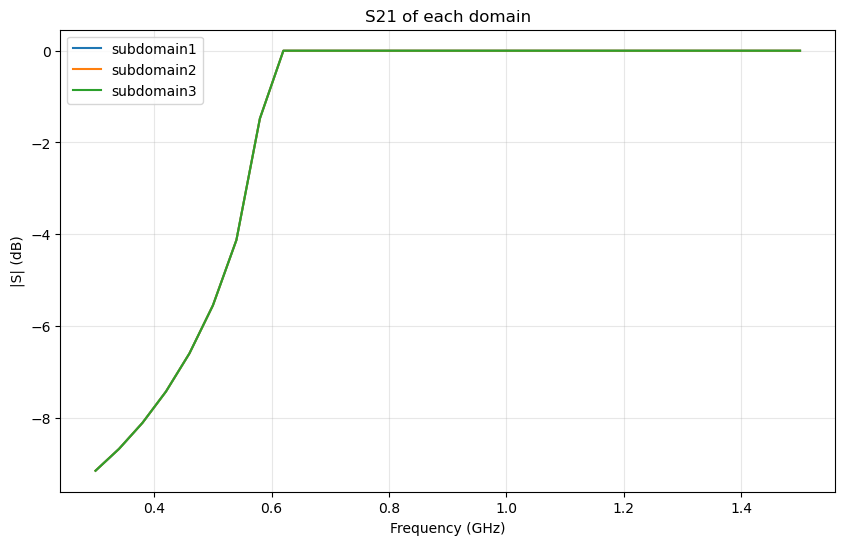

In [8]:
foms = proj.fds.foms
print(foms)

fig, ax = foms.plot_s(["1(1)2(1)"], title="S21 of each domain")

The three curves lie on top of each other: the three sections are identical.

## 3. Reduce and join

### 3.1 Reduce every domain

`foms.reduce()` builds one ROM per domain.

In [9]:
roms = foms.reduce(tol=1e-6)
print(roms)

Model Order Reduction


Reduction complete: 32565 -> 44 DOFs (99.9% compression)


ROMCollection([subdomain1, subdomain2, subdomain3])


### 3.2 Join the reduced models

`concatenate()` couples the three ROMs through their shared ports, `port2` and
`port3`, into one model with the two external ports. We sweep it at 2000
frequencies.

In [10]:
concat = roms.concatenate()
res = concat.solve(fmin=0.3, fmax=1.5, nsamples=2000)


Concat Solve: 0.3 - 1.5 GHz, 2000 samples, system size 42


  Concat solve complete: 0.022s (2000 frequencies)


The log line `Concat Solve: ... system size` gives the size of the joined
model: a few dozen unknowns for the whole 0.3 m guide.

## 4. Check against the exact solution

### 4.1 Compare the S-parameters

The joined model stands for the whole 0.3 m guide, so we compare it with the
exact solution for that length.

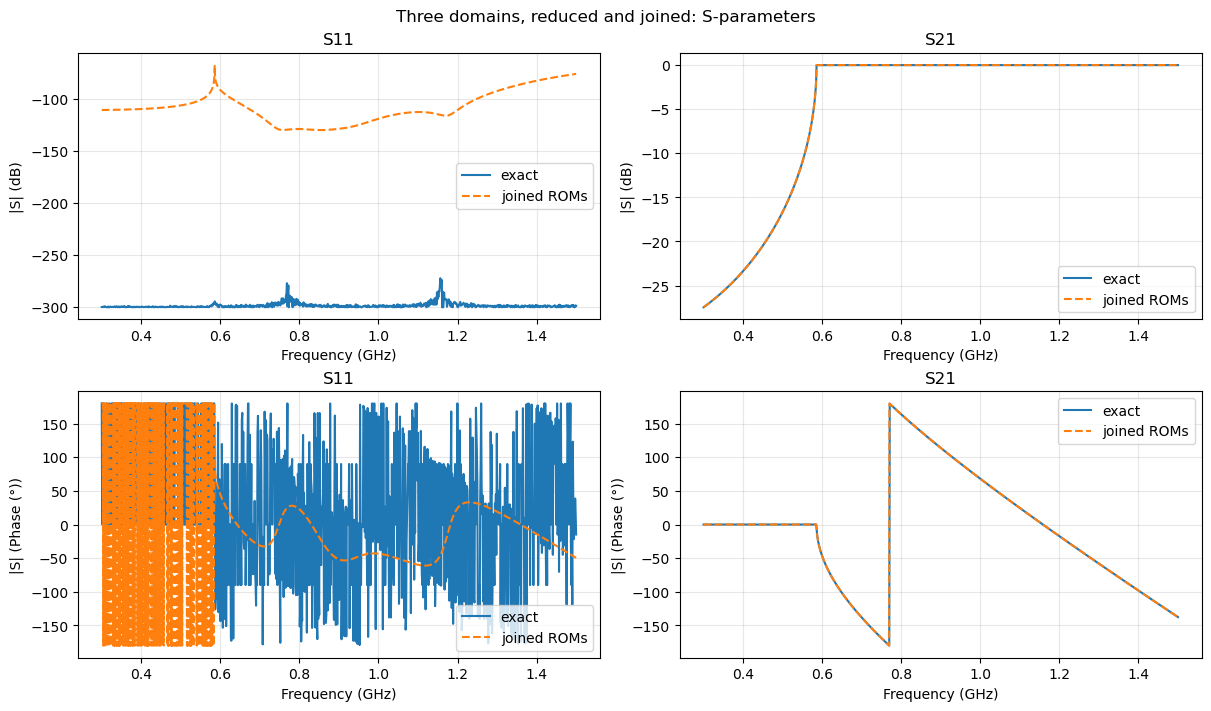

In [11]:
import matplotlib.pyplot as plt

from cavsim3d.analytical import CWGAnalytical

ana = CWGAnalytical(radius=0.15, length=0.3, freq_range=(0.3, 1.5))

fig, axs = plt.subplot_mosaic([["11 db", "21 db"], ["11 phase", "21 phase"]],
                              figsize=(12, 7), layout="constrained")
for ij in ("11", "21"):
    label = f"{ij[1]}(1){ij[0]}(1)"
    for kind in ("db", "phase"):
        ax = axs[f"{ij} {kind}"]
        ana.plot_s([label], plot_type=kind, ax=ax, label="exact")
        concat.plot_s([label], plot_type=kind, ax=ax, label="joined ROMs",
                      ls="--", title=f"S{ij}")
fig.suptitle("Three domains, reduced and joined: S-parameters")
plt.show()

The joined model follows the exact $S_{21}$ across the band. $S_{11}$ is
numerical noise, as for any uniform guide.

### 4.2 Compare the Z-parameters

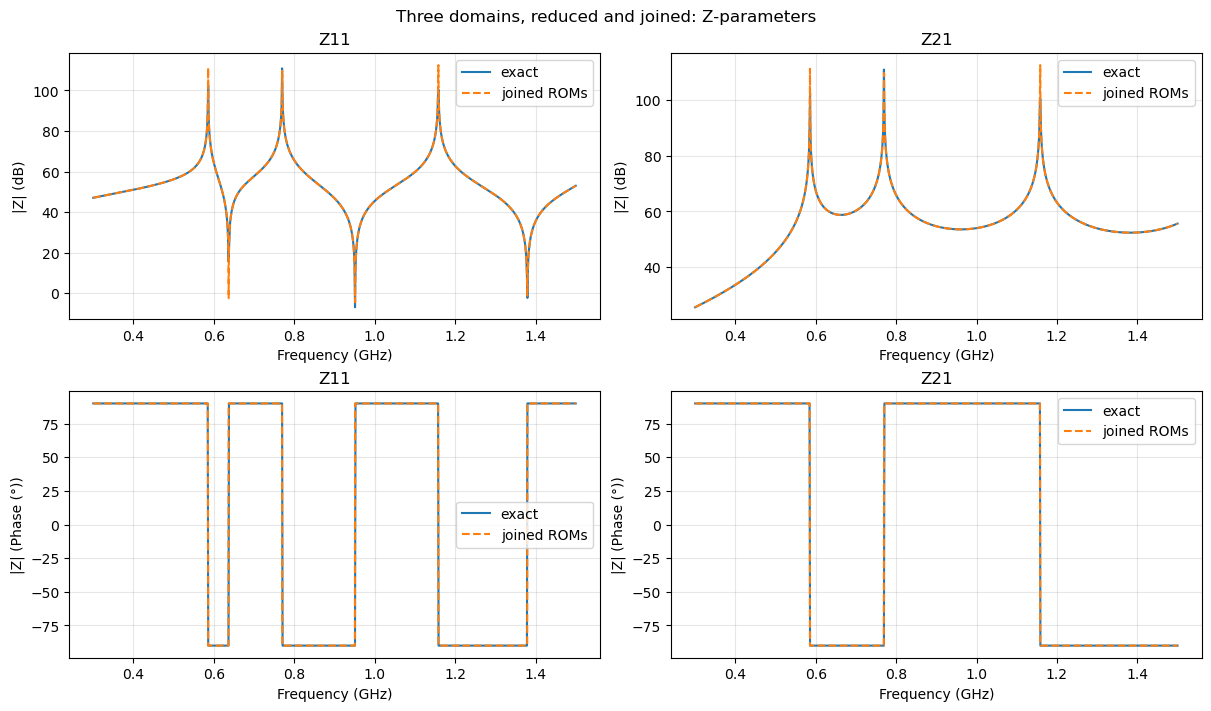

In [12]:
fig, axs = plt.subplot_mosaic([["11 db", "21 db"], ["11 phase", "21 phase"]],
                              figsize=(12, 7), layout="constrained")
for ij in ("11", "21"):
    label = f"{ij[1]}(1){ij[0]}(1)"
    for kind in ("db", "phase"):
        ax = axs[f"{ij} {kind}"]
        ana.plot_z([label], plot_type=kind, ax=ax, label="exact")
        concat.plot_z([label], plot_type=kind, ax=ax, label="joined ROMs",
                      ls="--", title=f"Z{ij}")
fig.suptitle("Three domains, reduced and joined: Z-parameters")
plt.show()

Every resonance peak of the whole guide is reproduced, although no domain on
its own has these resonances: they only exist once the domains are joined.

### 4.3 Measure the difference

In [13]:
import numpy as np

f = res["frequencies"]
S21_exact = ana.s_parameters(f / 1e9)["S21"]
err = np.abs(res["S"][:, 1, 0] - S21_exact)
above = f > 0.65e9
print(f"median |S21 - exact| above 0.65 GHz: {np.median(err[above]):.1e}")

median |S21 - exact| above 0.65 GHz: 2.4e-05


## What we did

We cut a CAD model into three domains with two planes, solved each domain on
its own, reduced each one, joined the reduced models through their shared
ports, and matched the result to the exact solution for the whole guide.

**Next:** [Fill a waveguide with lossy material](materials_and_losses.ipynb).

**Background:** [How a model is solved in pieces](../../explanation/architecture.md)
compares solving in one piece, per domain, and per domain after reduction.